# Plate → Text Split Pipeline

Load plate detector and plate splitter weights, run two-stage inference, and display bounding boxes/positions for each step.


province_classifier device: cuda


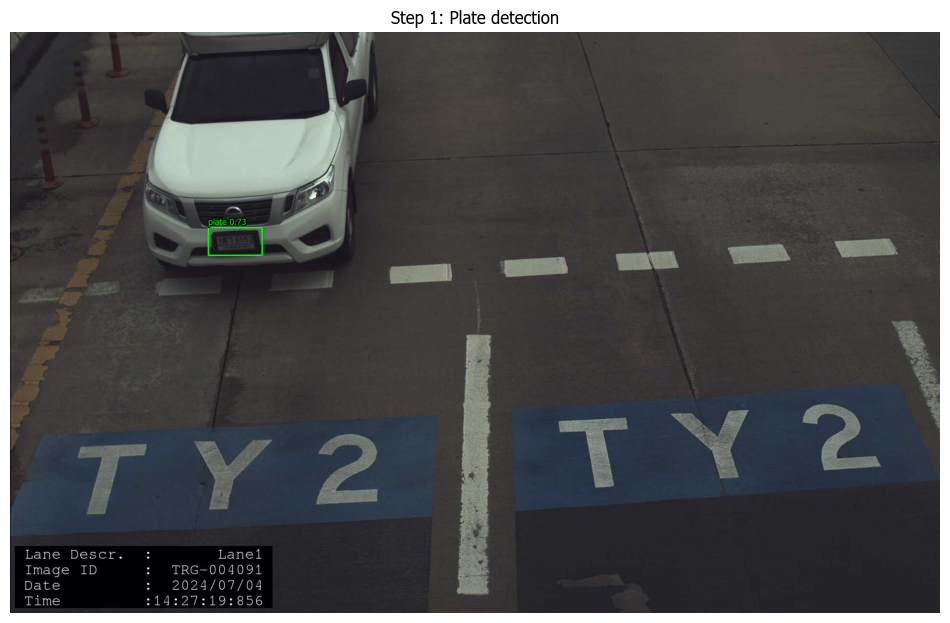

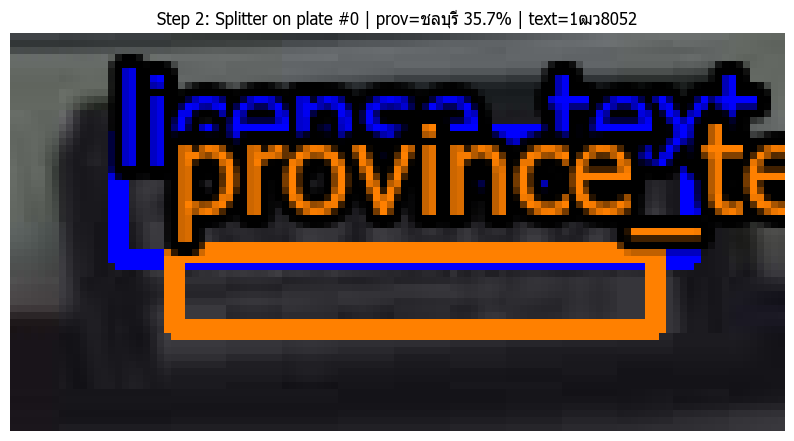

Plate 0 | license_text | text=1ฒว8052 0.75 | box=(15,14)-(97,32)
Plate 0 | province_text | prov=ชลบุรี 35.7% 0.59 | box=(23,31)-(92,42)
Plate detector time: 98.1 ms
Splitter time (plate 0): 42.9 ms
Province classifier time (plate 0): 4.2 ms
OCR time (plate 0): 3.4 ms
Avg splitter time: 42.9 ms
Avg province classifier time: 4.2 ms
Avg OCR time: 3.4 ms
Total inference (plate+split+province+ocr): 148.6 ms
Total end-to-end (this cell): 165.1 ms


In [9]:
from ultralytics import YOLO
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time

# Province classifier deps
import torch
import torch.nn.functional as F
import timm
import torchvision.transforms as T
from PIL import Image, ImageDraw, ImageFont

# ------------------------------
# Fonts (Thai): prefer Tahoma on Windows
def get_tahoma_font(size: int = 20):
    candidates = [
        r"C:\\Windows\\Fonts\\tahoma.ttf",
        r"C:\\Windows\\Fonts\\Tahoma.ttf",
    ]
    for p in candidates:
        try:
            return ImageFont.truetype(p, size=size)
        except Exception:
            pass
    # Fallback (may not support Thai well depending on env)
    return ImageFont.load_default()

TH_FONT_SMALL = get_tahoma_font(18)
TH_FONT_MED = get_tahoma_font(22)

# Matplotlib font (for Thai in titles/labels)
try:
    plt.rcParams['font.family'] = ['Tahoma']
except Exception:
    pass

def draw_text_thai_bgr(img_bgr: np.ndarray, text: str, org_xy: tuple[int, int],
                       font: ImageFont.ImageFont, fill_bgr=(0, 255, 0), stroke_bgr=(0, 0, 0), stroke_width: int = 2):
    if img_bgr is None or img_bgr.size == 0:
        return img_bgr
    rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    pil = Image.fromarray(rgb)
    draw = ImageDraw.Draw(pil)
    x, y = org_xy
    fill_rgb = (fill_bgr[2], fill_bgr[1], fill_bgr[0])
    stroke_rgb = (stroke_bgr[2], stroke_bgr[1], stroke_bgr[0])
    draw.text((x, y), text, font=font, fill=fill_rgb, stroke_width=stroke_width, stroke_fill=stroke_rgb)
    out = cv2.cvtColor(np.array(pil), cv2.COLOR_RGB2BGR)
    return out

# ------------------------------
# Paths to weights (update if moved)
WEIGHTS_DIR = Path(r"D:\CodingD\ALPR\weights")
PLATE_DET_W = WEIGHTS_DIR / "plate_detector_best.pt"
PLATE_SPLIT_W = WEIGHTS_DIR / "plate_splitter_best.pt"
# PROVINCE_CKPT = WEIGHTS_DIR / "province_classifier_best_old.pt"  # tf_efficientnet_b0 (old)
PROVINCE_CKPT = WEIGHTS_DIR / "province_classifier_best_new_model.pt"  # mobilenetv3_small_100 (new)
OCR_CKPT = WEIGHTS_DIR / "upper_ctc_special_best.pt"  # CTC OCR checkpoint (.pt), upper_ctc_best.pt for normal license plates

# Load models
plate_model = YOLO(PLATE_DET_W)  # plate detector (YOLOv11s)
splitter_model = YOLO(PLATE_SPLIT_W)  # plate splitter (YOLOv11n)

# Colors per class for splitter
SPLIT_COLORS = {0: (255, 0, 0), 1: (0, 128, 255)}  # BGR: license_text red-ish, province orange

# ------------------------------
# Province classifier helpers
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('province_classifier device:', device)

province_tfm = T.Compose([
    T.Resize((32, 128)),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

def load_province_classifier(ckpt_path: Path):
    if not ckpt_path.exists():
        raise FileNotFoundError(f"Province checkpoint not found: {ckpt_path}")
    ckpt = torch.load(str(ckpt_path), map_location=device)
    model = timm.create_model(ckpt['model_name'], pretrained=False, num_classes=ckpt['num_classes'], in_chans=3).to(device)
    model.load_state_dict(ckpt['state_dict'])
    model.eval()
    idx2label = ckpt.get('idx2label', None)
    if idx2label is None:
        # fallback: reconstruct from label2idx if present
        label2idx = ckpt.get('label2idx', {})
        idx2label = {int(v): k for k, v in label2idx.items()}
    else:
        # json may store keys as strings
        idx2label = {int(k): v for k, v in idx2label.items()}
    return model, idx2label

province_model, idx2label = load_province_classifier(PROVINCE_CKPT)

@torch.no_grad()
def predict_province_from_bgr(bgr_crop: np.ndarray, topk: int = 3):
    if bgr_crop is None or bgr_crop.size == 0:
        return []
    rgb = cv2.cvtColor(bgr_crop, cv2.COLOR_BGR2RGB)
    img = Image.fromarray(rgb)
    x = province_tfm(img).unsqueeze(0).to(device)
    logits = province_model(x)
    probs = F.softmax(logits, dim=1).squeeze(0)
    k = min(topk, probs.numel())
    vals, idxs = torch.topk(probs, k=k)
    out = []
    for v, i in zip(vals.cpu().tolist(), idxs.cpu().tolist()):
        out.append((idx2label.get(int(i), str(int(i))), float(v)))
    return out

# ------------------------------
# CTC OCR helpers
class CRNN(torch.nn.Module):
    def __init__(self, num_classes: int, img_height: int = 32):
        super().__init__()
        self.cnn = torch.nn.Sequential(
            torch.nn.Conv2d(1, 64, 3, 1, 1), torch.nn.BatchNorm2d(64), torch.nn.ReLU(True),
            torch.nn.MaxPool2d(2, 2),
            torch.nn.Conv2d(64, 128, 3, 1, 1), torch.nn.BatchNorm2d(128), torch.nn.ReLU(True),
            torch.nn.MaxPool2d(2, 2),
            torch.nn.Conv2d(128, 256, 3, 1, 1), torch.nn.BatchNorm2d(256), torch.nn.ReLU(True),
            torch.nn.Conv2d(256, 256, 3, 1, 1), torch.nn.BatchNorm2d(256), torch.nn.ReLU(True),
            torch.nn.MaxPool2d((2, 1), (2, 1)),
            torch.nn.Conv2d(256, 512, 3, 1, 1), torch.nn.BatchNorm2d(512), torch.nn.ReLU(True),
            torch.nn.MaxPool2d((2, 1), (2, 1)),
        )
        self.rnn = torch.nn.LSTM(512 * (img_height // 16), 256, num_layers=2, batch_first=True, bidirectional=True)
        self.classifier = torch.nn.Linear(256 * 2, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        feats = self.cnn(x)
        b, c, h, w = feats.size()
        feats = feats.permute(0, 3, 1, 2).contiguous()
        feats = feats.view(b, w, c * h)
        rnn_out, _ = self.rnn(feats)
        logits = self.classifier(rnn_out)
        return logits.permute(1, 0, 2)  # (T, B, C) for CTC

def load_ocr_model(ckpt_path: Path):
    if not ckpt_path.exists():
        raise FileNotFoundError(f"OCR checkpoint not found: {ckpt_path}")
    ckpt = torch.load(str(ckpt_path), map_location=device)
    idx_to_char = ckpt.get('idx_to_char', None)
    if idx_to_char is None:
        raise ValueError('idx_to_char not found in OCR checkpoint')
    model = CRNN(num_classes=len(idx_to_char)).to(device)
    model.load_state_dict(ckpt['model_state'])
    model.eval()
    return model, idx_to_char

ocr_model, ocr_idx_to_char = load_ocr_model(OCR_CKPT)

ocr_tfm = T.Compose([
    T.Resize((32, 128)),
    T.ToTensor(),
    T.Normalize((0.5,), (0.5,)),
])

@torch.no_grad()
def ocr_greedy_decode(logits: torch.Tensor) -> str:
    probs = logits.softmax(2)
    indices = probs.argmax(2).permute(1, 0)  # (B, T)
    seq = indices[0].tolist()
    prev = None
    chars = []
    for idx in seq:
        if idx != 0 and idx != prev:
            chars.append(ocr_idx_to_char[idx])
        prev = idx
    return "".join(chars)

@torch.no_grad()
def predict_text_from_bgr(bgr_crop: np.ndarray):
    if bgr_crop is None or bgr_crop.size == 0:
        return ""
    gray = cv2.cvtColor(bgr_crop, cv2.COLOR_BGR2GRAY)
    img = Image.fromarray(gray)
    x = ocr_tfm(img).unsqueeze(0).to(device)
    logits = ocr_model(x)
    return ocr_greedy_decode(logits)

# ------------------------------
def load_bgr(path: Path):
    img = cv2.imdecode(np.fromfile(str(path), dtype=np.uint8), cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f"Cannot load image: {path}")
    return img

def draw_boxes(img_bgr, boxes, labels=None, color=(0, 255, 0), thickness=2):
    img = img_bgr.copy()
    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)
        if labels:
            # Use PIL/Tahoma for Thai text
            img = draw_text_thai_bgr(img, labels[i], (x1, max(0, y1 - 24)), TH_FONT_SMALL, fill_bgr=color)
    return img

# --- User image ---
IMG_PATH = Path(r"D:\CodingD\ALPR\data\TEST_IMG\2024-07-04_14-27-19-856_TRG-004091_Lane1_18052-THA_10_CTX.jpg")  # change to your input
frame = load_bgr(IMG_PATH)

# ------------------------------
# Timed pipeline (per image)
t_all0 = time.perf_counter()

# Step 1: Plate detection (timed)
t0 = time.perf_counter()
plate_results = plate_model.predict(frame, conf=0.25, iou=0.7, imgsz=1280, verbose=False)[0]
plate_time = time.perf_counter() - t0
plate_boxes = plate_results.boxes.xyxy.cpu().numpy() if plate_results.boxes is not None else []
plate_confs = plate_results.boxes.conf.cpu().numpy() if plate_results.boxes is not None else []
plate_labels = [f"plate {c:.2f}" for c in plate_confs] if len(plate_confs) else []
vis_plate = draw_boxes(frame, plate_boxes, plate_labels, color=(0, 255, 0))

# Step 2: For each detected plate, run splitter (timed per plate)
split_viz_list = []
split_times = []
province_times = []  # list of (plate_idx, secs)
province_total_secs = 0.0
ocr_times = []  # list of (plate_idx, secs)
ocr_total_secs = 0.0
for idx, box in enumerate(plate_boxes):
    x1, y1, x2, y2 = map(int, box)
    plate_crop = frame[y1:y2, x1:x2]
    if plate_crop.size == 0:
        continue
    t1 = time.perf_counter()
    split_res = splitter_model.predict(plate_crop, conf=0.25, iou=0.6, imgsz=640, verbose=False)[0]
    split_time = time.perf_counter() - t1
    split_times.append((idx, split_time))
    split_boxes = split_res.boxes.xyxy.cpu().numpy() if split_res.boxes is not None else []
    split_cls = split_res.boxes.cls.cpu().numpy().astype(int) if split_res.boxes is not None else []
    split_confs = split_res.boxes.conf.cpu().numpy() if split_res.boxes is not None else []
    labels = []
    colors = []

    # Collect province prediction for this plate (if province box exists)
    province_pred_text = None
    ocr_pred_text = None

    for (b, c, s) in zip(split_boxes, split_cls, split_confs):
        name = splitter_model.names.get(int(c), str(int(c)))
        # If this is the province region, run classifier on that crop (timed)
        if int(c) == 1:
            x1s, y1s, x2s, y2s = map(int, b)
            prov_crop = plate_crop[y1s:y2s, x1s:x2s]
            tpc0 = time.perf_counter()
            top = predict_province_from_bgr(prov_crop, topk=3)
            tpc = time.perf_counter() - tpc0
            province_times.append((idx, tpc))
            province_total_secs += tpc
            if top:
                province_pred_text = f"prov={top[0][0]} {top[0][1]*100:.1f}%"
                name = f"{name} | {province_pred_text}"
        # If this is the license_text region, run OCR (timed)
        if int(c) == 0:
            x1s, y1s, x2s, y2s = map(int, b)
            text_crop = plate_crop[y1s:y2s, x1s:x2s]
            toc0 = time.perf_counter()
            text_pred = predict_text_from_bgr(text_crop)
            toc = time.perf_counter() - toc0
            ocr_times.append((idx, toc))
            ocr_total_secs += toc
            if text_pred:
                ocr_pred_text = f"text={text_pred}"
                name = f"{name} | {ocr_pred_text}"
        labels.append(f"{name} {s:.2f}")
        colors.append(SPLIT_COLORS.get(int(c), (255, 255, 0)))

    crop_viz = plate_crop.copy()
    for b, lbl, clr in zip(split_boxes, labels, colors):
        x1s, y1s, x2s, y2s = map(int, b)
        cv2.rectangle(crop_viz, (x1s, y1s), (x2s, y2s), clr, 2)
        crop_viz = draw_text_thai_bgr(crop_viz, lbl, (x1s, max(0, y1s - 24)), TH_FONT_SMALL, fill_bgr=clr)
    split_viz_list.append((idx, crop_viz, split_boxes, labels, province_pred_text, ocr_pred_text))

t_all = time.perf_counter() - t_all0

# --- Visualization ---
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(vis_plate, cv2.COLOR_BGR2RGB))
plt.title("Step 1: Plate detection")
plt.axis('off')
plt.show()

if not split_viz_list:
    print("No plates found; adjust confidence or check input image path.")
else:
    for idx, crop_viz, s_boxes, s_labels, prov_text, text_pred in split_viz_list:
        plt.figure(figsize=(10, 6))
        plt.imshow(cv2.cvtColor(crop_viz, cv2.COLOR_BGR2RGB))
        title = f"Step 2: Splitter on plate #{idx}"
        if prov_text:
            title += f" | {prov_text}"
        if text_pred:
            title += f" | {text_pred}"
        plt.title(title)
        plt.axis('off')
        plt.show()
        # Print positions
        for b, lbl in zip(s_boxes, s_labels):
            x1, y1, x2, y2 = map(int, b)
            print(f"Plate {idx} | {lbl} | box=({x1},{y1})-({x2},{y2})")

# --- Timing summary ---
print(f"Plate detector time: {plate_time*1000:.1f} ms")
for idx, st in split_times:
    print(f"Splitter time (plate {idx}): {st*1000:.1f} ms")
for idx, st in province_times:
    print(f"Province classifier time (plate {idx}): {st*1000:.1f} ms")
for idx, st in ocr_times:
    print(f"OCR time (plate {idx}): {st*1000:.1f} ms")

if split_times:
    avg_split = sum(st for _, st in split_times) / len(split_times)
    print(f"Avg splitter time: {avg_split*1000:.1f} ms")
if province_times:
    avg_prov = sum(st for _, st in province_times) / len(province_times)
    print(f"Avg province classifier time: {avg_prov*1000:.1f} ms")
if ocr_times:
    avg_ocr = sum(st for _, st in ocr_times) / len(ocr_times)
    print(f"Avg OCR time: {avg_ocr*1000:.1f} ms")

sum_split = sum(st for _, st in split_times)
sum_prov = sum(st for _, st in province_times)
sum_ocr = sum(st for _, st in ocr_times)
print(f"Total inference (plate+split+province+ocr): {(plate_time + sum_split + sum_prov + sum_ocr)*1000:.1f} ms")
print(f"Total end-to-end (this cell): {t_all*1000:.1f} ms")

# Evaluation on img_all (labels.csv)
วัด Accuracy, CER, WER, detection rates และเวลาประมวลผลแต่ละขั้น (plate → split → province/OCR).

In [10]:
from __future__ import annotations

from pathlib import Path
import pandas as pd
import numpy as np
import time

# ------------------------------
# Config
IMG_ROOT = Path("data/test_images")
LABELS_CSV = IMG_ROOT / "labels.csv"
MAX_SAMPLES = None  # set to int for quick test (e.g., 500)

# ------------------------------
# Helpers
def normalize_rel(p: str) -> str:
    return str(p).replace("\\", "/").replace("/", "\\").lstrip("\\")

def levenshtein_seq(a, b) -> int:
    # Works for strings or lists
    n, m = len(a), len(b)
    if n == 0:
        return m
    if m == 0:
        return n
    dp = list(range(m + 1))
    for i in range(1, n + 1):
        prev = dp[0]
        dp[0] = i
        for j in range(1, m + 1):
            cur = dp[j]
            cost = 0 if a[i - 1] == b[j - 1] else 1
            dp[j] = min(
                dp[j] + 1,      # deletion
                dp[j - 1] + 1,  # insertion
                prev + cost     # substitution
            )
            prev = cur
    return dp[m]

def cer(gt: str, pred: str) -> float:
    gt = "" if gt is None else str(gt)
    pred = "" if pred is None else str(pred)
    dist = levenshtein_seq(gt, pred)
    return dist / max(1, len(gt))

def wer(gt: str, pred: str) -> float:
    gt_words = str(gt).split()
    pred_words = str(pred).split()
    dist = levenshtein_seq(gt_words, pred_words)
    return dist / max(1, len(gt_words))

def p95(x: list[float]) -> float:
    return float(np.percentile(np.array(x), 95)) if x else 0.0

# ------------------------------
# Build filename -> full path mapping
print("Building image index...")
img_files = {}
for img_path in IMG_ROOT.rglob("*.jpg"):
    img_files[img_path.name] = img_path
print(f"Found {len(img_files)} images in {IMG_ROOT}")

# ------------------------------
# Load labels
df = pd.read_csv(LABELS_CSV)
required_cols = {"plate", "province_description", "image_name_gray"}
missing_cols = required_cols - set(df.columns)
if missing_cols:
    raise ValueError(f"Missing columns in labels.csv: {missing_cols}")

# Extract filename only and match to actual files
df["filename"] = df["image_name_gray"].astype(str).apply(lambda p: Path(p).name)
df["image_path"] = df["filename"].map(img_files)
df = df[df["image_path"].notna()].reset_index(drop=True)

if MAX_SAMPLES is not None and len(df) > MAX_SAMPLES:
    df = df.sample(MAX_SAMPLES, random_state=42).reset_index(drop=True)

print(f"Eval rows (matched by filename): {len(df)}")

# ------------------------------
# Evaluation loop
plate_found = 0
text_box_found = 0
prov_box_found = 0

text_acc = 0
prov_acc = 0
cer_list = []
wer_list = []

t_plate = []
t_split = []
t_ocr = []
t_prov = []
t_total = []

# For confusion matrix (province)
y_true_prov = []
y_pred_prov = []

for _, row in df.iterrows():
    gt_text = str(row["plate"]).strip()
    gt_prov = str(row["province_description"]).strip()
    img_path = Path(row["image_path"])

    frame = load_bgr(img_path)
    t0 = time.perf_counter()

    # Step 1: plate detector
    t1 = time.perf_counter()
    plate_results = plate_model.predict(frame, conf=0.25, iou=0.7, imgsz=1280, verbose=False)[0]
    t_plate.append(time.perf_counter() - t1)
    plate_boxes = plate_results.boxes.xyxy.cpu().numpy() if plate_results.boxes is not None else []
    plate_confs = plate_results.boxes.conf.cpu().numpy() if plate_results.boxes is not None else []
    if len(plate_boxes) == 0:
        t_total.append(time.perf_counter() - t0)
        cer_list.append(cer(gt_text, ""))
        wer_list.append(wer(gt_text, ""))
        y_true_prov.append(gt_prov)
        y_pred_prov.append("<MISS>")
        continue
    plate_found += 1
    best_idx = int(np.argmax(plate_confs))
    x1, y1, x2, y2 = map(int, plate_boxes[best_idx])
    plate_crop = frame[y1:y2, x1:x2]
    if plate_crop.size == 0:
        t_total.append(time.perf_counter() - t0)
        cer_list.append(cer(gt_text, ""))
        wer_list.append(wer(gt_text, ""))
        y_true_prov.append(gt_prov)
        y_pred_prov.append("<MISS>")
        continue

    # Step 2: splitter
    t2 = time.perf_counter()
    split_res = splitter_model.predict(plate_crop, conf=0.25, iou=0.6, imgsz=640, verbose=False)[0]
    t_split.append(time.perf_counter() - t2)
    split_boxes = split_res.boxes.xyxy.cpu().numpy() if split_res.boxes is not None else []
    split_cls = split_res.boxes.cls.cpu().numpy().astype(int) if split_res.boxes is not None else []
    split_confs = split_res.boxes.conf.cpu().numpy() if split_res.boxes is not None else []

    # Select best text/province boxes by confidence
    text_pred = ""
    prov_pred = ""

    # license_text class = 0
    text_idxs = [i for i, c in enumerate(split_cls) if int(c) == 0]
    if text_idxs:
        text_box_found += 1
        best_t = max(text_idxs, key=lambda i: split_confs[i])
        x1t, y1t, x2t, y2t = map(int, split_boxes[best_t])
        text_crop = plate_crop[y1t:y2t, x1t:x2t]
        t3 = time.perf_counter()
        text_pred = predict_text_from_bgr(text_crop)
        t_ocr.append(time.perf_counter() - t3)
    else:
        t_ocr.append(0.0)

    # province class = 1
    prov_idxs = [i for i, c in enumerate(split_cls) if int(c) == 1]
    if prov_idxs:
        prov_box_found += 1
        best_p = max(prov_idxs, key=lambda i: split_confs[i])
        x1p, y1p, x2p, y2p = map(int, split_boxes[best_p])
        prov_crop = plate_crop[y1p:y2p, x1p:x2p]
        t4 = time.perf_counter()
        top = predict_province_from_bgr(prov_crop, topk=1)
        t_prov.append(time.perf_counter() - t4)
        if top:
            prov_pred = str(top[0][0])
    else:
        t_prov.append(0.0)
        prov_pred = "<MISS>"

    # Metrics
    if text_pred == gt_text:
        text_acc += 1
    if prov_pred == gt_prov:
        prov_acc += 1
    cer_list.append(cer(gt_text, text_pred))
    wer_list.append(wer(gt_text, text_pred))

    y_true_prov.append(gt_prov)
    y_pred_prov.append(prov_pred)

    t_total.append(time.perf_counter() - t0)

# ------------------------------
# Summary
n = len(df)
plate_rate = plate_found / max(1, n)
text_box_rate = text_box_found / max(1, plate_found)
prov_box_rate = prov_box_found / max(1, plate_found)

text_acc_all = text_acc / max(1, n)
prov_acc_all = prov_acc / max(1, n)

print("=== Detection / Split rates ===")
print(f"Plate detection rate: {plate_rate*100:.2f}% ({plate_found}/{n})")
print(f"Text box found rate: {text_box_rate*100:.2f}% ({text_box_found}/{max(1, plate_found)})")
print(f"Province box found rate: {prov_box_rate*100:.2f}% ({prov_box_found}/{max(1, plate_found)})")

print("=== Accuracy ===")
print(f"Plate text exact match acc: {text_acc_all*100:.2f}%")
print(f"Province exact match acc: {prov_acc_all*100:.2f}%")
print(f"CER (avg): {float(np.mean(cer_list)):.4f}")
print(f"WER (avg): {float(np.mean(wer_list)):.4f}")

print("=== Timing (ms) ===")
def ms(x):
    return [v * 1000 for v in x]
if t_plate:
    print(f"Plate detector: mean={np.mean(ms(t_plate)):.1f} p95={p95(ms(t_plate)):.1f}")
if t_split:
    print(f"Splitter: mean={np.mean(ms(t_split)):.1f} p95={p95(ms(t_split)):.1f}")
if t_prov:
    print(f"Province cls: mean={np.mean(ms(t_prov)):.1f} p95={p95(ms(t_prov)):.1f}")
if t_ocr:
    print(f"OCR: mean={np.mean(ms(t_ocr)):.1f} p95={p95(ms(t_ocr)):.1f}")
if t_total:
    print(f"End-to-end: mean={np.mean(ms(t_total)):.1f} p95={p95(ms(t_total)):.1f} | FPS={1.0/max(1e-9, np.mean(t_total)):.2f}")

print("=== Confusion Matrix (province) ===")
labels = sorted(set(y_true_prov) | set(y_pred_prov))
cm = pd.crosstab(pd.Series(y_true_prov, name="true"), pd.Series(y_pred_prov, name="pred"), dropna=False)
print(cm)

print("=== Top Confusions (province) ===")
conf = cm.copy()
for lbl in cm.index:
    if lbl in conf.columns:
        conf.loc[lbl, lbl] = 0
conf_flat = conf.stack().sort_values(ascending=False)
print(conf_flat.head(20))

print("=== Thesis-ready metrics (suggested) ===")
print("- Plate detection rate, split success rate (text/province), OCR exact match acc")
print("- CER/WER for OCR")
print("- Province top-1 acc + confusion matrix")
print("- Per-stage latency (mean/p95) and end-to-end FPS")
print("- Failure cases: no plate / no text / no province")


Building image index...
Found 334 images in data\test_images
Eval rows (matched by filename): 334
=== Detection / Split rates ===
Plate detection rate: 99.10% (331/334)
Text box found rate: 100.00% (331/331)
Province box found rate: 99.70% (330/331)
=== Accuracy ===
Plate text exact match acc: 94.31%
Province exact match acc: 97.60%
CER (avg): 0.0210
WER (avg): 0.0569
=== Timing (ms) ===
Plate detector: mean=17.4 p95=18.2
Splitter: mean=7.3 p95=9.0
Province cls: mean=4.0 p95=4.6
OCR: mean=2.3 p95=3.0
End-to-end: mean=31.9 p95=34.5 | FPS=31.36
=== Confusion Matrix (province) ===
pred             <MISS>  กรุงเทพมหานคร  กาฬสินธุ์  กำแพงเพชร  ขอนแก่น  \
true                                                                    
กรุงเทพมหานคร         4            247          0          0        0   
กาฬสินธุ์             0              0          1          0        0   
กำแพงเพชร             0              0          0          1        0   
ขอนแก่น               0              0          0 